In [100]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
plt.style.use("seaborn-v0_8")

In [101]:
# Step1 Generate Toy(Dummy) Dataset

X, y = make_blobs(n_samples=2000, n_features=2, cluster_std=3, centers=2, random_state=42)
n_features = 2
print(X.shape, y.shape)

(2000, 2) (2000,)


In [102]:
# Step2 Visualise Dataset

def visualise(X,y):
  plt.scatter(X[:,0], X[:,1],c=y, cmap="gist_rainbow_r")
  plt.show()

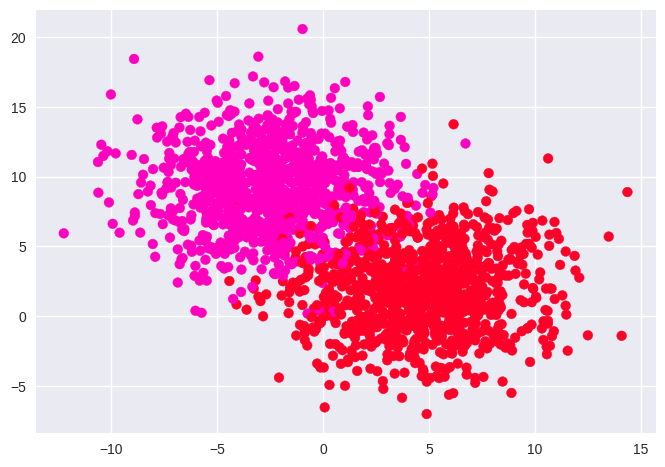

In [103]:
visualise(X,y)

In [104]:
# Step3 Nomalise

def normalise(X):
  u = X.mean(axis=0)
  std = X.std(axis=0)

  return (X-u)/std

In [105]:
X = normalise(X)

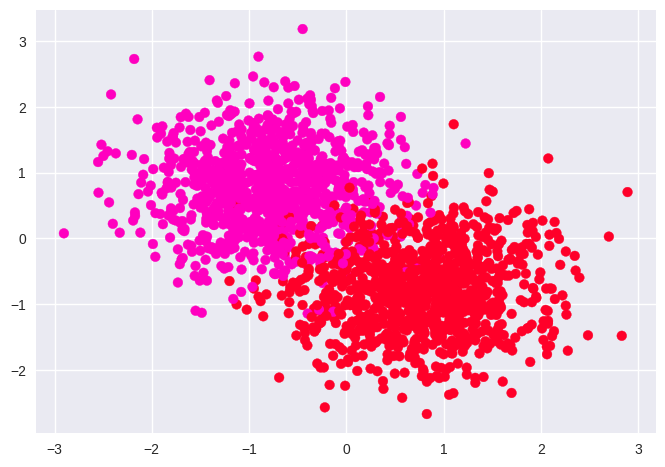

In [106]:
visualise(X,y)

In [107]:
# Step4 Train Test split
XT, Xt, yT, yt = train_test_split(X, y, test_size=0.25, shuffle=False, random_state=0)

print(XT.shape, yT.shape)
print(Xt.shape, yt.shape)


(1500, 2) (1500,)
(500, 2) (500,)


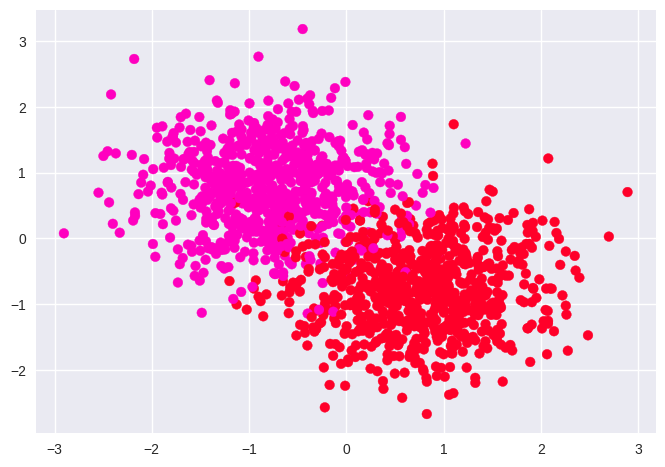

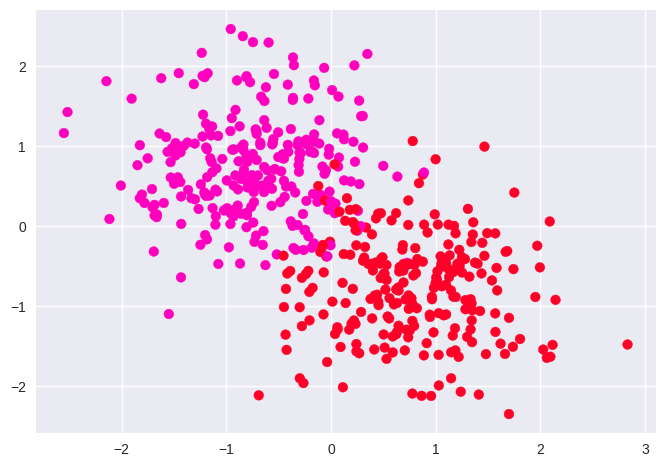

In [108]:
visualise(XT, yT)
visualise(Xt, yt)

In [120]:
# Step5 Model
def sigmoid(z):
  return 1 / (1 + np.exp(-z))

def hypothesis(X, theta):
  return sigmoid(np.dot(X, theta))

def error(y, yp):
  loss = -np.mean(y*np.log(yp) + (1-y)*np.log(1-yp))
  return loss

def gradient(X, y, yp):
  m = X.shape[0]
  grad = -(1/m) * np.dot(X.T, (y-yp))
  return grad

def train(X, y, max_iters=100, learning_rate=0.1):
  # Randomly initialise thea
  theta = np.random.randn(n_features + 1, 1)
  error_list = []

  for i in range(max_iters):
    yp = hypothesis(X, theta)
    e = error(y, yp)
    error_list.append(e)
    grad = gradient(X, y, yp)
    theta = theta - learning_rate * grad

  plt.plot(error_list)
  return theta

def predict(X, theta):
  h = hypothesis(X, theta)
  preds = np.zeros((X.shape[0], 1), dtype='i')
  preds[h >= 0.5] = 1

  return preds

def accuracy(X, y, theta):
  preds = predict(X, theta)
  return ((y==preds).sum())/y.shape[0] * 100

In [110]:
def addExtraColumn(X):
  if X.shape[1] == n_features:
    ones = np.ones((X.shape[0], 1))
    X = np.hstack((ones, X))

  return X

In [111]:
XT = addExtraColumn(XT)
print(XT)

[[ 1.         -1.43211741  0.65078613]
 [ 1.         -0.47100516  0.87372191]
 [ 1.         -0.40182883  2.1275269 ]
 ...
 [ 1.          0.02390726  0.74454457]
 [ 1.         -0.35936993  0.18771848]
 [ 1.          1.09360417 -1.10077065]]


In [112]:
Xt = addExtraColumn(Xt)
print(Xt)

[[ 1.         -1.17860853  1.9119189 ]
 [ 1.          0.70445084 -1.55536144]
 [ 1.          0.39063944 -0.10336496]
 ...
 [ 1.          1.96970601 -0.24632291]
 [ 1.         -0.80805197 -0.01411826]
 [ 1.          0.83964924  0.53655099]]


In [113]:
yT = yT.reshape(-1, 1)
yt = yt.reshape(-1, 1)

In [114]:
print(yT.shape)
print(yt.shape)

(1500, 1)
(500, 1)


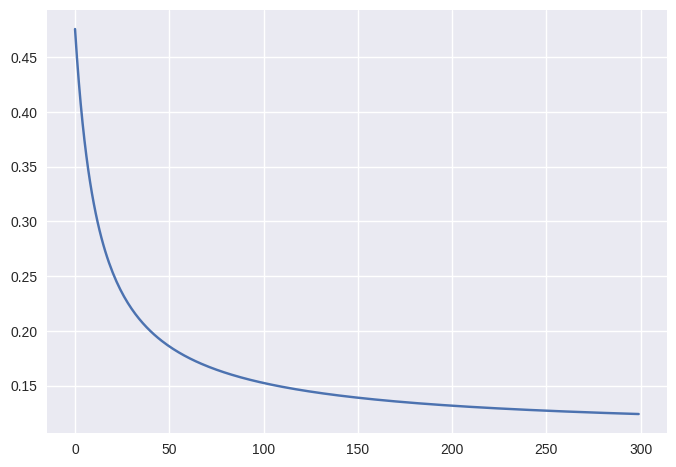

In [115]:
theta = train(XT, yT, max_iters=300, learning_rate=0.2)

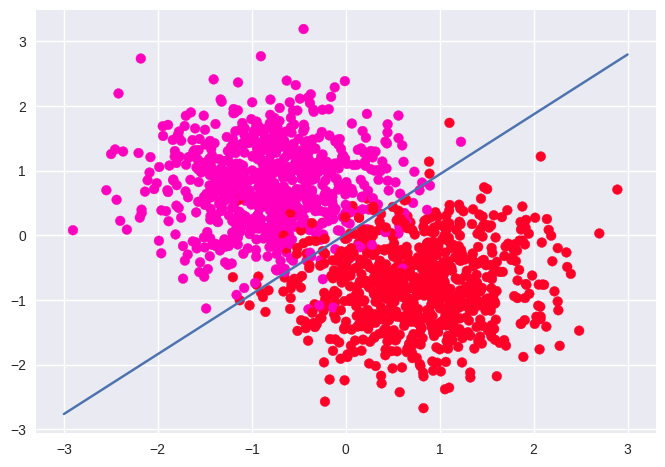

In [116]:
plt.scatter(XT[:,1], XT[:,2],c=yT, cmap="gist_rainbow_r")
x1 = np.linspace(-3, 3, 6)
x2 = -(theta[0] + theta[1]*x1)/theta[2]
plt.plot(x1, x2)
plt.show()

In [118]:
preds = predict(Xt, theta)

In [121]:
accuracy(XT, yT, theta)

np.float64(95.8)

In [122]:
accuracy(Xt, yt, theta)

np.float64(96.2)